In [1]:
import pandas

In [3]:
!pip install pybaseball

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 97.3 MB/s eta 0:00:00


In [4]:
import pybaseball
from pybaseball import statcast

pybaseball.cache.enable()


In [6]:
sc = statcast(start_dt="2025-03-27", end_dt="2025-09-30")
sc = sc[[
    "game_date", "game_pk", "pitcher", "player_name", "batter",
    "pitch_type", "release_speed", "release_spin_rate",
    "description", "events", "inning", "outs_when_up",
    "home_team", "away_team", "stand", "p_throws"
]]

This is a large query, it may take a moment to complete


 98%|█████████▊| 184/188 [00:09<00:00, 21.10it/s]/usr/local/lib/python3.12/dist-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
100%|██████████| 188/188 [00:12<00:00, 14.72it/s]
/usr/local/lib/python3.12/dist-packages/pybaseball/statcast.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_data = pd.concat(dataframe_list, axis=0).convert_dtypes(convert_string=False)


In [22]:
sc["is_k"] = sc["events"].isin(["strikeout", "strikeout_double_play"]).astype(int)

# swinging strike flag
sc["is_whiff"] = sc["description"].isin([
    "swinging_strike",
    "swinging_strike_blocked"
]).astype(int)

pitcher_games = (
    sc.groupby(["game_date", "game_pk", "pitcher", "player_name"])
      .agg(
          pitches=("pitch_type", "count"),
          strikeouts=("is_k", "sum"),
          whiffs=("is_whiff", "sum"),
          avg_velo=("release_speed", "mean"),
          avg_spin=("release_spin_rate", "mean"),
          batters_faced=("batter", "nunique")
      )
      .reset_index()
)

pitcher_games["whiff_per_pitch"] = pitcher_games["whiffs"] / pitcher_games["pitches"]

In [23]:
pitcher_games = pitcher_games.sort_values(["pitcher", "game_date"]).copy()

for col in ["strikeouts", "pitches", "batters_faced", "whiff_per_pitch", "avg_velo", "avg_spin"]:
    pitcher_games[f"{col}_last3"] = (
        pitcher_games.groupby("pitcher")[col]
        .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
    )
    pitcher_games[f"{col}_last10"] = (
        pitcher_games.groupby("pitcher")[col]
        .transform(lambda s: s.shift(1).rolling(10, min_periods=3).mean())
    )

In [24]:
import numpy as np

pitcher_games["k_per_pitch_last10"] = (
    pitcher_games["strikeouts_last10"] / pitcher_games["pitches_last10"]
)

pitcher_games["k_rate_last10"] = (
    pitcher_games["strikeouts_last10"] / pitcher_games["batters_faced_last10"]
)

pitcher_games["k_per_pitch_last10"] = pitcher_games["k_per_pitch_last10"].replace([np.inf, -np.inf], np.nan)
pitcher_games["k_rate_last10"] = pitcher_games["k_rate_last10"].replace([np.inf, -np.inf], np.nan)

In [27]:
features = [
    "pitches_last3",
    "pitches_last10",
    "whiff_per_pitch_last3",
    "avg_velo_last3",
    "avg_spin_last3",
    "k_per_pitch_last10",
    "k_rate_last10"
]
X = pitcher_games[features]

In [28]:
model_df = pitcher_games[features + ["strikeouts"]].dropna()

X = model_df[features]
y = model_df["strikeouts"]

In [29]:
import sklearn
import xgboost
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

sklearn: 1.6.1
xgboost: 3.2.0


In [32]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    reg_lambda=1.0,
    random_state=42
)

In [34]:
import pandas as pd

features = [
    "pitches_last3",
    "pitches_last10",
    "whiff_per_pitch_last3",
    "avg_velo_last3",
    "avg_spin_last3",
    "k_per_pitch_last10",
    "k_rate_last10",
]

model_df = pitcher_games[["game_date", "pitcher", "strikeouts"] + features].copy()
model_df["game_date"] = pd.to_datetime(model_df["game_date"])

model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=["strikeouts"] + features)
model_df = model_df.sort_values("game_date")

In [39]:
split_date = pd.Timestamp("2025-08-01")

train_df = model_df[model_df["game_date"] < split_date].copy()
test_df  = model_df[model_df["game_date"] >= split_date].copy()

X_train = train_df[features]
y_train = train_df["strikeouts"]

X_test = test_df[features]
y_test = test_df["strikeouts"]

In [40]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "objective": "reg:squarederror",
    "max_depth": 4,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42,
    "eval_metric": "mae",
}

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=200,
    evals=[(dtrain, "train"), (dtest, "test")],
    verbose_eval=False,
)

preds = bst.predict(dtest)
mae = mean_absolute_error(y_test, preds)

print("Test MAE:", mae)

Test MAE: 1.0448354482650757


In [43]:
print(model_df.corr()["strikeouts"].sort_values(ascending=False))

strikeouts               1.000000
pitches_last10           0.730849
pitches_last3            0.730780
k_rate_last10            0.649955
game_date                0.033651
pitcher                  0.008333
k_per_pitch_last10      -0.011088
whiff_per_pitch_last3   -0.033560
avg_spin_last3          -0.038838
avg_velo_last3          -0.069020
Name: strikeouts, dtype: float64


In [42]:
latest_rows = (
    model_df.sort_values("game_date")
    .groupby("pitcher", as_index=False)
    .tail(1)
    .copy()
)

tomorrow_X = latest_rows[features]
dtomorrow = xgb.DMatrix(tomorrow_X)

latest_rows["predicted_ks"] = bst.predict(dtomorrow)
print(latest_rows[["pitcher", "predicted_ks"]].head(20))

      pitcher  predicted_ks
1452   690829      0.960251
1669   687847      1.078590
1655   622780      1.029600
2011   669212      0.949691
2178   666619      0.905020
2123   605182      0.817524
2313   663474      1.420892
2407   640462      1.109654
2621   606930      1.105914
2901   600917      1.300195
2885   666120      1.284860
3097   670174      1.401963
3411   664849      1.051376
3312   687362      4.365476
3409   621345      0.977888
3595   663372      4.186065
3683   628317      1.143524
3963   680729      1.021768
3932   685801      0.977965
4133   682171      0.843346


0.5838262 8.372796


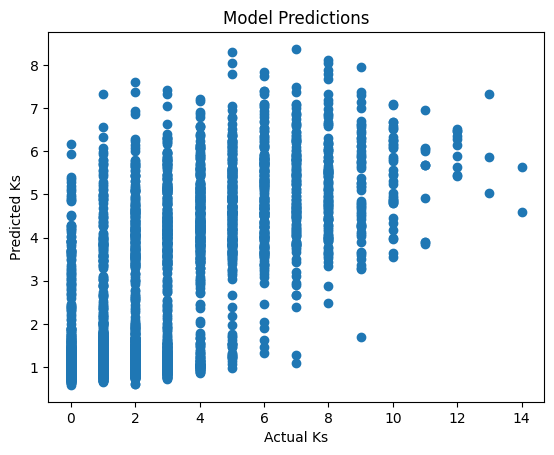

In [44]:
import matplotlib.pyplot as plt
print(preds.min(), preds.max())
plt.scatter(y_test, preds)
plt.xlabel("Actual Ks")
plt.ylabel("Predicted Ks")
plt.title("Model Predictions")
plt.show()

In [19]:
tomorrow_preds["edge"] = tomorrow_preds["predicted_ks"] - tomorrow_preds["vegas_line"]

NameError: name 'tomorrow_preds' is not defined